<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/Lenet_5_mnist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9294 - loss: 0.2380 - val_accuracy: 0.9648 - val_loss: 0.1120
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9736 - loss: 0.0864 - val_accuracy: 0.9713 - val_loss: 0.0904
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9822 - loss: 0.0588 - val_accuracy: 0.9810 - val_loss: 0.0591
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9862 - loss: 0.0448 - val_accuracy: 0.9822 - val_loss: 0.0550
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9878 - loss: 0.0370 - val_accuracy: 0.9862 - val_loss: 0.0423


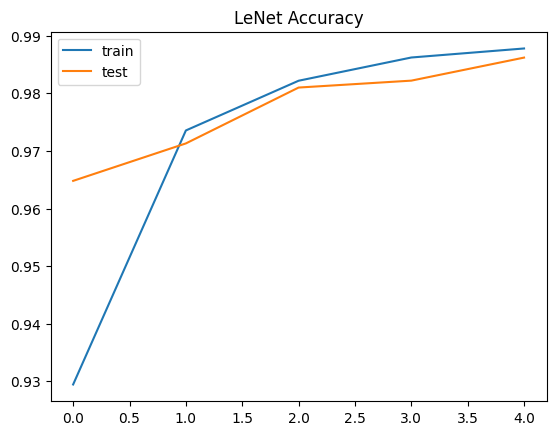

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

# Model
model = models.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(6,(5,5),activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16,(5,5),activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(120,activation='tanh'),
    layers.Dense(84,activation='tanh'),
    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("LeNet Accuracy")
plt.legend(["train","test"])
plt.show()